# Passing Lanes

In [37]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mplsoccer import Pitch
from matplotlib.lines import Line2D

In [2]:
DATA_DIR = Path("../data")

home_path = DATA_DIR / "Sample_Game_1_RawTrackingData_Home_Team.csv"
away_path = DATA_DIR / "Sample_Game_1_RawTrackingData_Away_Team.csv"
events_path = DATA_DIR / "Sample_Game_1_RawEventsData.csv"

In [3]:
home = pd.read_csv(home_path, skiprows=2)
away = pd.read_csv(away_path, skiprows=2)
events = pd.read_csv(events_path)

In [6]:
PITCH_LENGTH = 105
PITCH_WIDTH = 68

### Helper functions

In [4]:
def clean_tracking_columns(df):
    df = df.copy()
    cols = list(df.columns)

    for i in range(3, len(cols), 2):
        name = cols[i]
        cols[i] = f"{name}_x"
        cols[i + 1] = f"{name}_y"

    df.columns = cols
    return df

In [5]:
def convert_tracking_to_metres(df):
    df = df.copy()

    x_cols = [c for c in df.columns if c.endswith("_x")]
    y_cols = [c for c in df.columns if c.endswith("_y")]

    df[x_cols] = df[x_cols] * PITCH_LENGTH
    df[y_cols] = (1 - df[y_cols]) * PITCH_WIDTH

    return df


In [7]:
def convert_event_coordinates(df):
    df = df.copy()

    for col in ["Start X", "End X"]:
        df[col] = df[col] * PITCH_LENGTH

    for col in ["Start Y", "End Y"]:
        df[col] = (1 - df[col]) * PITCH_WIDTH

    return df

In [8]:
def active_players(frame, x_cols):
    players = []

    for x_col in x_cols:
        y_col = x_col.replace("_x", "_y")
        player = x_col.replace("_x", "")

        if pd.notna(frame[x_col]) and pd.notna(frame[y_col]):
            players.append((player, frame[x_col], frame[y_col]))

    return players

## Clean data

In [9]:
home = clean_tracking_columns(home)
away = clean_tracking_columns(away)

In [10]:
home = convert_tracking_to_metres(home)
away = convert_tracking_to_metres(away)

In [11]:
events = convert_event_coordinates(events)

In [12]:
home_x_cols = [
    c for c in home.columns
    if c.startswith("Player") and c.endswith("_x")
]

away_x_cols = [
    c for c in away.columns
    if c.startswith("Player") and c.endswith("_x")
]

Sanity check.

In [13]:
print(home.shape)
print(away.shape)
print(events.shape)

print(home["Ball_x"].min(), home["Ball_x"].max())
print(home["Ball_y"].min(), home["Ball_y"].max())

(145006, 33)
(145006, 33)
(1745, 14)
-4.7754 111.2958
-2.5717599999999976 70.71387999999999


## Select a pass event

First filter to completed pass events with a known passer, receiver, and start frame.

In [14]:
passes = events[
    (events["Type"] == "PASS") &
    events["From"].notna() &
    events["To"].notna() &
    events["Start Frame"].notna()
].copy()

passes[
    ["Team", "From", "To", "Start Frame", "Start Time [s]",
     "Start X", "Start Y", "End X", "End Y"]
].head(10)

,Team,From,To,Start Frame,Start Time [s],Start X,Start Y,End X,End Y
1,Away,Player19,Player21,1,0.04,47.25,41.48,57.75,38.76
2,Away,Player21,Player15,3,0.12,57.75,38.76,60.90,53.72
3,Away,Player15,Player19,45,1.80,57.75,55.08,47.25,46.92
4,Away,Player19,Player21,77,3.08,47.25,46.24,51.45,36.04
5,Away,Player21,Player22,191,7.64,42.00,18.36,33.60,1.36
6,Away,Player22,Player17,279,11.16,40.95,2.72,51.45,1.36
15,Home,Player2,Player9,498,19.92,37.80,22.44,55.65,27.88
16,Home,Player9,Player10,536,21.44,55.65,27.88,52.50,23.80
19,Away,Player16,Player19,763,30.52,60.90,49.64,53.55,45.56
20,Away,Player19,Player20,784,31.36,53.55,45.56,59.85,36.04


I avoid using the very first pass in the match, because kickoff situations are atypical.

In [15]:
candidate_passes = passes[
    passes["Start Time [s]"] > 300
]

pass_event = candidate_passes.iloc[0]

pass_event[
    ["Team", "From", "To", "Start Frame", "Start Time [s]",
     "Start X", "Start Y", "End X", "End Y"]
]

Team                  Away
From              Player19
To                Player18
Start Frame           7519
Start Time [s]      300.76
Start X               27.3
Start Y              48.28
End X                30.45
End Y                63.24
Name: 104, dtype: object

Extract some information.

In [16]:
pass_frame = int(pass_event["Start Frame"])
pass_team = pass_event["Team"]
passer = pass_event["From"]
receiver = pass_event["To"]

print("Frame:", pass_frame)
print("Time:", pass_event["Start Time [s]"])
print("Team:", pass_team)
print("Passer:", passer)
print("Receiver:", receiver)

Frame: 7519
Time: 300.76
Team: Away
Passer: Player19
Receiver: Player18


Grab the corresponding tracking frame.

In [17]:
home_frame = home.loc[home["Frame"] == pass_frame].iloc[0]
away_frame = away.loc[away["Frame"] == pass_frame].iloc[0]

In [18]:
print(events["Team"].unique())

<ArrowStringArray>
['Away', 'Home']
Length: 2, dtype: str


### Define attacking and defending team

In [19]:
if pass_team == "Home":
    attacking_frame = home_frame
    defending_frame = away_frame
    attacking_x_cols = home_x_cols
    defending_x_cols = away_x_cols
else:
    attacking_frame = away_frame
    defending_frame = home_frame
    attacking_x_cols = away_x_cols
    defending_x_cols = home_x_cols

In [20]:
attackers = active_players(attacking_frame, attacking_x_cols)
defenders = active_players(defending_frame, defending_x_cols)

print("Attackers:", len(attackers))
print("Defenders:", len(defenders))

Attackers: 11
Defenders: 11


Locate the passer and the receiver.

In [21]:
passer_xy = (
    attacking_frame[f"{passer}_x"],
    attacking_frame[f"{passer}_y"]
)

receiver_xy = (
    attacking_frame[f"{receiver}_x"],
    attacking_frame[f"{receiver}_y"]
)

print("Passer:", passer, passer_xy)
print("Receiver:", receiver, receiver_xy)

Passer: Player19 (27.81765, 48.52344)
Receiver: Player18 (28.730099999999997, 62.96664)


Define every other attacker as a passing option.

In [22]:
passing_options = [
    (player, x, y)
    for player, x, y in attackers
    if player != passer
]

print("Number of passing options:", len(passing_options))

for option in passing_options:
    print(option)

Number of passing options: 10
('Player25', 81.3099, 34.84592)
('Player15', 40.97205, 55.87764)
('Player16', 50.18685, 45.83064)
('Player17', 39.4863, 32.40472)
('Player18', 28.730099999999997, 62.96664)
('Player20', 34.53765, 40.671479999999995)
('Player21', 20.303849999999997, 58.36848)
('Player22', 21.02835, 15.16196)
('Player23', 20.52225, 41.70643999999999)
('Player24', 12.9717, 47.02472)


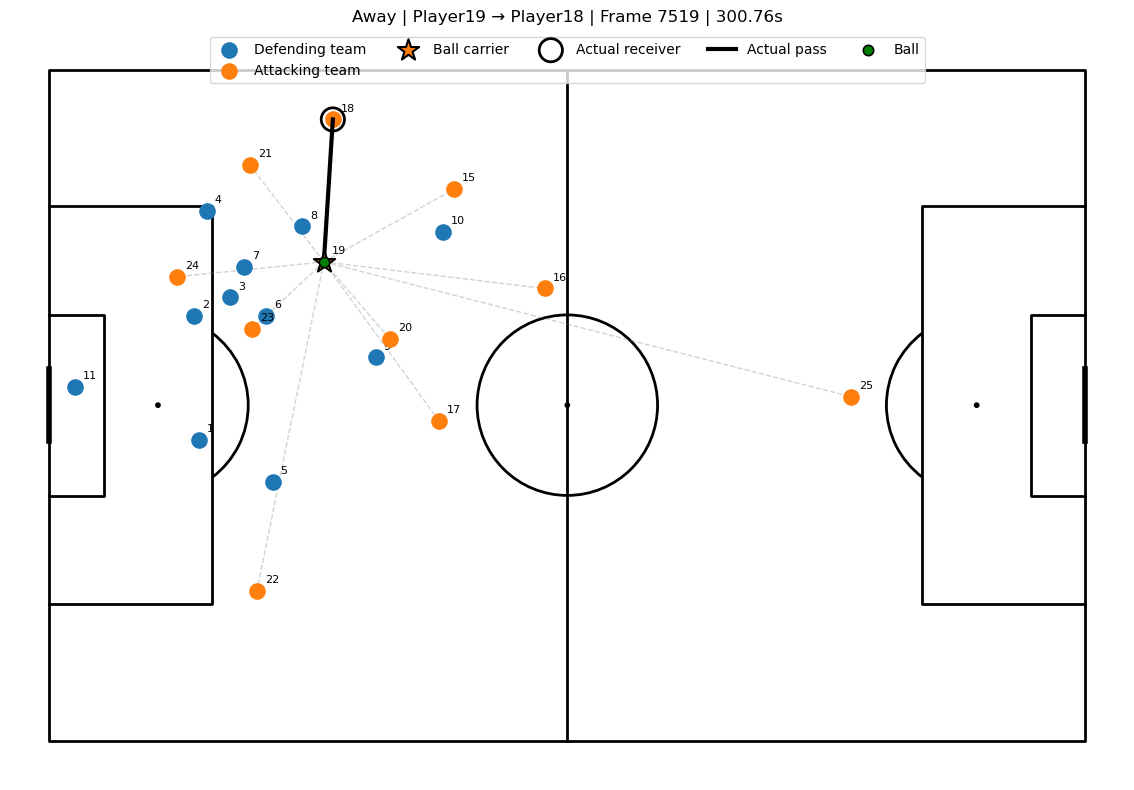

In [24]:
pitch = Pitch(
    pitch_type="custom",
    pitch_length=105,
    pitch_width=68,
    pitch_color="white",
    line_color="black"
)

fig, ax = pitch.draw(figsize=(12, 8))

# Team colors
attacking_color = "tab:orange"
defending_color = "tab:blue"

# --- Defenders ---
def_x = [x for _, x, _ in defenders]
def_y = [y for _, _, y in defenders]

ax.scatter(
    def_x, def_y,
    s=120,
    color=defending_color,
    zorder=3,
    label="Defending team"
)

for player, x, y in defenders:
    ax.text(
        x + 0.8, y + 0.8,
        player.replace("Player", ""),
        fontsize=8
    )

# --- Attacking players / passing options ---
opt_x = [x for _, x, _ in passing_options]
opt_y = [y for _, _, y in passing_options]

ax.scatter(
    opt_x, opt_y,
    s=120,
    color=attacking_color,
    zorder=3,
    label="Attacking team"
)

for player, x, y in passing_options:
    # Candidate passing lane
    ax.plot(
        [passer_xy[0], x],
        [passer_xy[1], y],
        linestyle="--",
        linewidth=1,
        alpha=0.35,
        color="gray",
        zorder=1
    )

    ax.text(
        x + 0.8, y + 0.8,
        player.replace("Player", ""),
        fontsize=8
    )

# --- Ball carrier ---
ax.scatter(
    passer_xy[0],
    passer_xy[1],
    s=260,
    color=attacking_color,
    marker="*",
    edgecolor="black",
    linewidth=1.5,
    zorder=5,
    label="Ball carrier"
)

# label ball carrier too
ax.text(
    passer_xy[0] + 0.8, passer_xy[1] + 0.8,
    passer.replace("Player", ""),
    fontsize=8
)

# --- Actual receiver ---
ax.scatter(
    receiver_xy[0],
    receiver_xy[1],
    s=280,
    facecolors="none",
    edgecolors="black",
    linewidth=2,
    zorder=5,
    label="Actual receiver"
)

# --- Actual pass ---
ax.plot(
    [passer_xy[0], receiver_xy[0]],
    [passer_xy[1], receiver_xy[1]],
    linewidth=3,
    color="black",
    zorder=4,
    label="Actual pass"
)

# --- Ball ---
ax.scatter(
    attacking_frame["Ball_x"],
    attacking_frame["Ball_y"],
    s=55,
    color="green",
    edgecolor="black",
    linewidth=1.2,
    zorder=6,
    label="Ball"
)

ax.set_title(
    f"{pass_team} | {passer} → {receiver} | "
    f"Frame {pass_frame} | {pass_event['Start Time [s]']:.2f}s"
)

ax.legend(loc="upper center", ncol=5)
plt.show()

### Defender distance to passing lane

In [25]:
def point_to_segment_distance(point, start, end):
    """
    Minimum Euclidean distance from a point to a line segment.

    point, start, end: (x, y)
    """
    point = np.array(point, dtype=float)
    start = np.array(start, dtype=float)
    end = np.array(end, dtype=float)

    segment = end - start

    # Avoid division by zero
    if np.allclose(segment, 0):
        return np.linalg.norm(point - start)

    t = np.dot(point - start, segment) / np.dot(segment, segment)

    # Restrict projection to the actual pass segment
    t = np.clip(t, 0, 1)

    closest_point = start + t * segment

    return np.linalg.norm(point - closest_point)

Calculate the closest defender to every candidate passing option.

In [26]:
lane_results = []

for receiver_player, rx, ry in passing_options:

    receiver_point = (rx, ry)

    defender_distances = []

    for defender, dx, dy in defenders:
        distance = point_to_segment_distance(
            point=(dx, dy),
            start=passer_xy,
            end=receiver_point
        )

        defender_distances.append((defender, distance))

    closest_defender, min_distance = min(
        defender_distances,
        key=lambda x: x[1]
    )

    lane_results.append({
        "receiver": receiver_player,
        "closest_defender": closest_defender,
        "distance_to_lane": min_distance
    })

In [27]:
lane_results = pd.DataFrame(lane_results)

lane_results.sort_values("distance_to_lane")

,receiver,closest_defender,distance_to_lane
8,Player23,Player6,0.044272
9,Player24,Player7,0.308966
6,Player21,Player8,0.418717
7,Player22,Player5,0.632337
3,Player17,Player9,1.435282
5,Player20,Player9,2.356039
4,Player18,Player8,2.443304
1,Player15,Player10,3.222073
0,Player25,Player8,4.229794
2,Player16,Player8,4.229794


Add more context, such as how far the defender is to the pass receiver, or the lenght of the possible pass.

In [30]:
def point_to_segment_metrics(point, start, end):
    point = np.array(point, dtype=float)
    start = np.array(start, dtype=float)
    end = np.array(end, dtype=float)

    segment = end - start
    length_sq = np.dot(segment, segment)

    if length_sq == 0:
        return np.linalg.norm(point - start), 0

    # Raw position along infinite line
    t = np.dot(point - start, segment) / length_sq

    # Closest point on actual pass segment
    t_clipped = np.clip(t, 0, 1)
    closest_point = start + t_clipped * segment

    distance = np.linalg.norm(point - closest_point)

    return distance, t

In [31]:
lane_results = []

for receiver_player, rx, ry in passing_options:

    receiver_point = (rx, ry)
    pass_length = np.linalg.norm(
        np.array(receiver_point) - np.array(passer_xy)
    )

    defender_metrics = []

    for defender, dx, dy in defenders:

        distance, t = point_to_segment_metrics(
            point=(dx, dy),
            start=passer_xy,
            end=receiver_point
        )

        defender_metrics.append(
            (defender, distance, t)
        )

    closest_defender, min_distance, t = min(
        defender_metrics,
        key=lambda x: x[1]
    )

    lane_results.append({
        "receiver": receiver_player,
        "pass_length": pass_length,
        "closest_defender": closest_defender,
        "distance_to_lane": min_distance,
        "position_along_lane": t
    })

lane_results = pd.DataFrame(lane_results)

lane_results.sort_values("distance_to_lane")

,receiver,pass_length,closest_defender,distance_to_lane,position_along_lane
8,Player23,9.984706,Player6,0.044272,0.801639
9,Player24,14.921407,Player7,0.308966,0.539956
6,Player21,12.384749,Player8,0.418717,0.339855
7,Player22,34.045307,Player5,0.632337,0.672111
3,Player17,19.899008,Player9,1.435282,0.548570
5,Player20,10.334973,Player9,2.356039,1.041458
4,Player18,14.471993,Player8,2.443304,0.238581
1,Player15,15.070584,Player10,3.222073,0.796660
0,Player25,55.213181,Player8,4.229794,-0.055119
2,Player16,22.530696,Player8,4.229794,-0.116955


Interpret position_along_lane as:
- 0.0  = right next to passer
- 0.5  = halfway along pass
- 1.0  = right next to receiver

### Passing lane obstruction

Initially only consider defenders who are between the passer and the receiver (like not behind the passer for example).

Lane clearance = perpendicular distance of the closest defender whose projection lies between passer and receiver.
- Player23: ~0.04 m → extremely obstructed
- Player24: ~0.31 m → very obstructed
- Player21: ~0.42 m → very obstructed
- Player18 (actual receiver): ~2.44 m → considerably more open

In [34]:
lane_results = []

for receiver_player, rx, ry in passing_options:
    
    receiver_point = (rx, ry)

    pass_length = np.linalg.norm(
        np.array(receiver_point) - np.array(passer_xy)
    )

    valid_defenders = []

    for defender, dx, dy in defenders:
        distance, t = point_to_segment_metrics(
            point=(dx, dy),
            start=passer_xy,
            end=receiver_point   # IMPORTANT: receiver-specific endpoint
        )

        # Only defenders whose projection lies between
        # passer and receiver can obstruct the lane
        if 0 < t < 1:
            valid_defenders.append(
                (defender, distance, t)
            )

    if valid_defenders:
        closest_defender, lane_clearance, position = min(
            valid_defenders,
            key=lambda x: x[1]
        )
    else:
        closest_defender = None
        lane_clearance = np.nan
        position = np.nan

    lane_results.append({
        "receiver": receiver_player,
        "receiver_x": rx,
        "receiver_y": ry,
        "pass_length": pass_length,
        "closest_defender": closest_defender,
        "lane_clearance": lane_clearance,
        "position_along_lane": position
    })

lane_results = pd.DataFrame(lane_results)

lane_results.sort_values("lane_clearance")

,receiver,receiver_x,receiver_y,pass_length,closest_defender,lane_clearance,position_along_lane
8,Player23,20.52225,41.70644,9.984706,Player6,0.044272,0.801639
9,Player24,12.97170,47.02472,14.921407,Player7,0.308966,0.539956
6,Player21,20.30385,58.36848,12.384749,Player8,0.418717,0.339855
7,Player22,21.02835,15.16196,34.045307,Player5,0.632337,0.672111
3,Player17,39.48630,32.40472,19.899008,Player9,1.435282,0.548570
4,Player18,28.73010,62.96664,14.471993,Player8,2.443304,0.238581
1,Player15,40.97205,55.87764,15.070584,Player10,3.222073,0.796660
2,Player16,50.18685,45.83064,22.530696,Player10,4.464970,0.514916
0,Player25,81.30990,34.84592,55.213181,Player10,5.936968,0.197808
5,Player20,34.53765,40.67148,10.334973,Player6,7.994577,0.038066


In [35]:
def lane_color(clearance):
    if pd.isna(clearance):
        return "gray"
    elif clearance < 1:
        return "red"
    elif clearance < 2.5:
        return "orange"
    else:
        return "green"

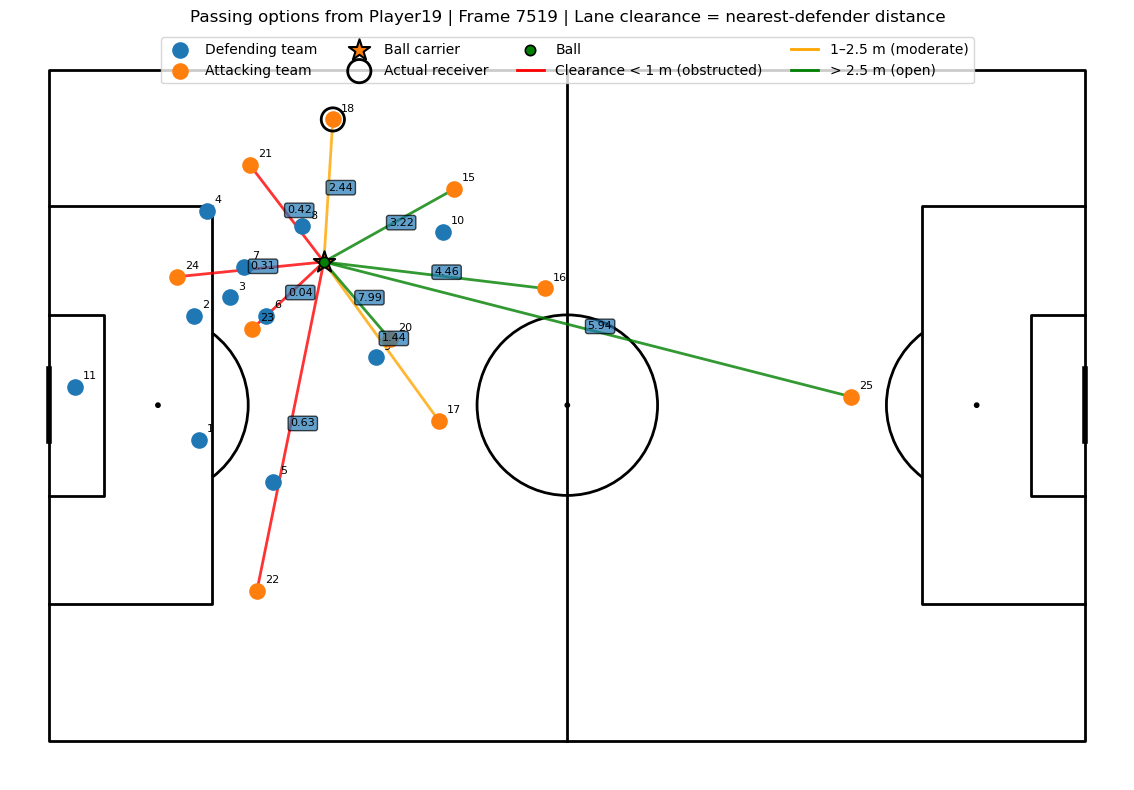

In [39]:
pitch = Pitch(
    pitch_type="custom",
    pitch_length=105,
    pitch_width=68,
    pitch_color="white",
    line_color="black"
)

fig, ax = pitch.draw(figsize=(12, 8))

attacking_color = "tab:orange"
defending_color = "tab:blue"

# Plot defenders
ax.scatter(
    [x for _, x, _ in defenders],
    [y for _, _, y in defenders],
    s=120,
    color=defending_color,
    zorder=3,
    label="Defending team"
)

for player, x, y in defenders:
    ax.text(x + 0.8, y + 0.8, player.replace("Player", ""), fontsize=8)

# Plot attacking teammates (except passer)
ax.scatter(
    [x for _, x, _ in passing_options],
    [y for _, _, y in passing_options],
    s=120,
    color=attacking_color,
    zorder=3,
    label="Attacking team"
)

for player, x, y in passing_options:
    ax.text(x + 0.8, y + 0.8, player.replace("Player", ""), fontsize=8)

# Plot lanes with color based on clearance
for _, row in lane_results.iterrows():
    color = lane_color(row["lane_clearance"])

    ax.plot(
        [passer_xy[0], row["receiver_x"]],
        [passer_xy[1], row["receiver_y"]],
        color=color,
        linewidth=2,
        alpha=0.8,
        zorder=2
    )

    # write clearance value near midpoint of lane
    mid_x = (passer_xy[0] + row["receiver_x"]) / 2
    mid_y = (passer_xy[1] + row["receiver_y"]) / 2

    ax.text(
        mid_x, mid_y,
        f"{row['lane_clearance']:.2f}",
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.2", alpha=0.7)
    )

# Ball carrier
ax.scatter(
    passer_xy[0], passer_xy[1],
    s=260,
    color=attacking_color,
    marker="*",
    edgecolor="black",
    linewidth=1.5,
    zorder=5,
    label="Ball carrier"
)

# Actual receiver
ax.scatter(
    receiver_xy[0], receiver_xy[1],
    s=280,
    facecolors="none",
    edgecolors="black",
    linewidth=2,
    zorder=5,
    label="Actual receiver"
)

# Ball
ax.scatter(
    attacking_frame["Ball_x"],
    attacking_frame["Ball_y"],
    s=55,
    color="green",
    edgecolor="black",
    linewidth=1.2,
    zorder=6,
    label="Ball"
)

ax.set_title(
    f"Passing options from {passer} | Frame {pass_frame} | "
    f"Lane clearance = nearest-defender distance"
)

clearance_legend = [
    Line2D([0], [0], color="red", lw=2, label="Clearance < 1 m (obstructed)"),
    Line2D([0], [0], color="orange", lw=2, label="1–2.5 m (moderate)"),
    Line2D([0], [0], color="green", lw=2, label="> 2.5 m (open)")
]

handles, labels = ax.get_legend_handles_labels()
handles.extend(clearance_legend)

ax.legend(handles=handles, loc="upper center", ncol=4)
plt.show()